In [12]:
import pandas as pd
import os
from vnstock import Vnstock
import matplotlib.pyplot as plt

# Khai báo tham số theo đúng phạm vi nghiên cứu
tickers = ['VCB', 'BID', 'CTG']
start_date = '2016-01-01'
end_date = '2025-12-31'

# Tạo thư mục lưu trữ nếu chưa có
os.makedirs('../data/raw', exist_ok=True)

raw_data_dict = {}
print("Đang tải dữ liệu từ vnstock (V3)...")

for ticker in tickers:
    try:
        # Khởi tạo đối tượng mã chứng khoán (Nguồn VCI)
        stock = Vnstock().stock(symbol=ticker, source='VCI')
        
        # Trích xuất dữ liệu giá lịch sử
        df = stock.quote.history(start=start_date, end=end_date, interval='1D')
        
        # Chuẩn hóa tên cột về chữ thường cho đồng nhất
        df.columns = [col.lower() for col in df.columns]
        
        # Lưu vào Dictionary và xuất ra file CSV
        raw_data_dict[ticker] = df
        df.to_csv(f'../data/raw/{ticker}_historical_data.csv', index=False)
        
        print(f"✅ Đã tải thành công {len(df)} phiên giao dịch của {ticker}")
    except Exception as e:
        print(f"❌ Lỗi khi tải {ticker}: {e}")

# In thử 5 dòng đầu của VCB để kiểm tra cấu trúc OHLCV
display(raw_data_dict['VCB'].head())

Đang tải dữ liệu từ vnstock (V3)...
✅ Đã tải thành công 2611 phiên giao dịch của VCB
✅ Đã tải thành công 2611 phiên giao dịch của BID
✅ Đã tải thành công 2611 phiên giao dịch của CTG


,time,open,high,low,close,volume
0,2015-07-29,15.47,15.62,15.32,15.32,396810
1,2015-07-30,15.32,15.32,15.02,15.32,320770
2,2015-07-31,15.47,15.47,14.99,14.99,373390
3,2015-08-03,14.96,14.96,14.05,14.38,1106740
4,2015-08-04,14.32,14.45,13.81,13.81,747010


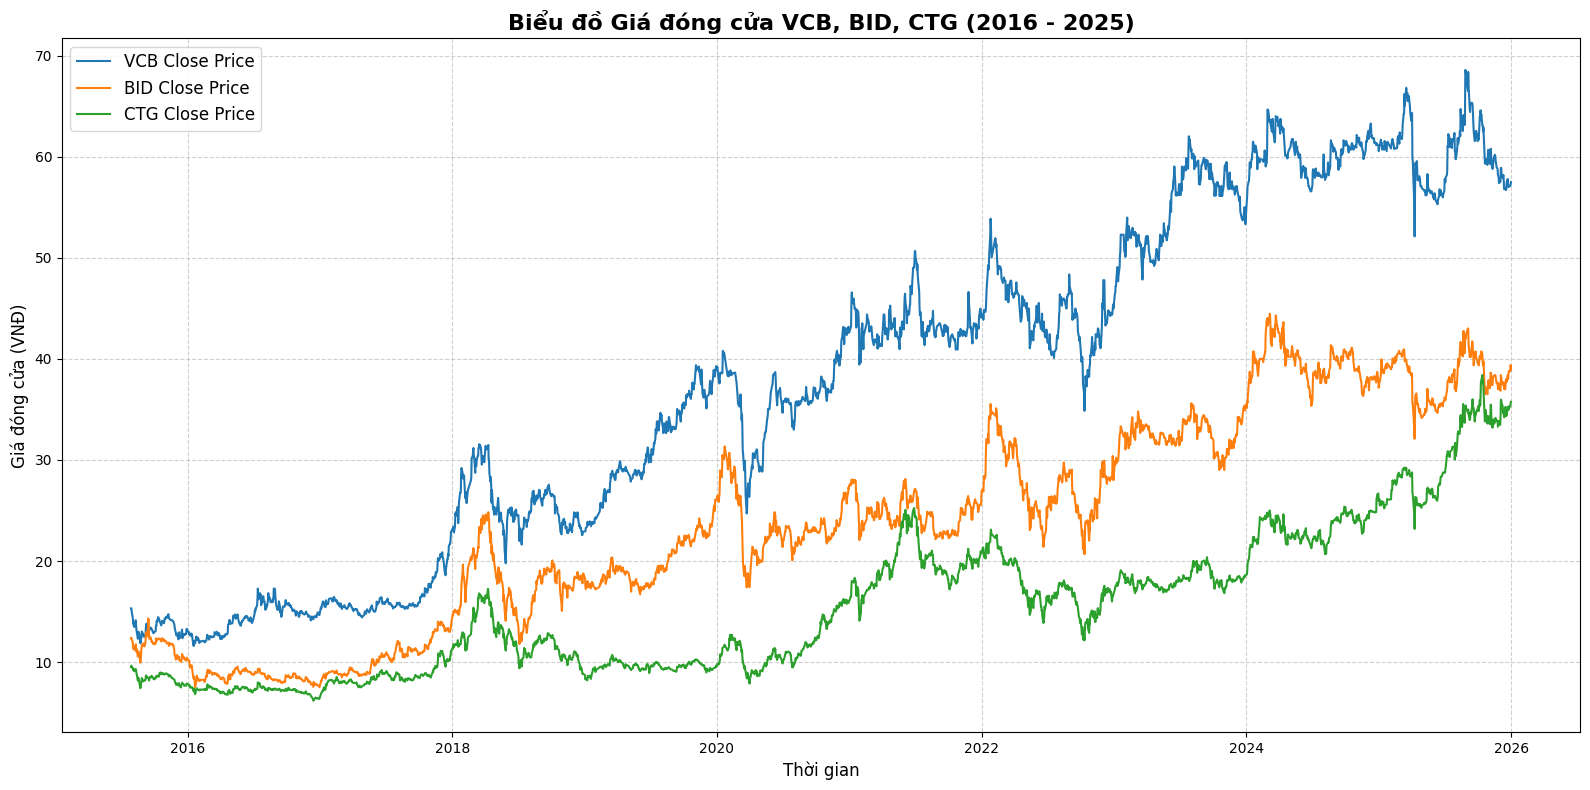

In [13]:
# Trực quan hóa biến động giá đóng cửa của bộ 3 ngân hàng
plt.figure(figsize=(16, 8))

for ticker in tickers:
    df_plot = raw_data_dict[ticker].copy()
    # Ép kiểu cột time về dạng datetime để vẽ biểu đồ chuẩn xác
    df_plot['time'] = pd.to_datetime(df_plot['time'])
    plt.plot(df_plot['time'], df_plot['close'], label=f'{ticker} Close Price', linewidth=1.5)

plt.title('Biểu đồ Giá đóng cửa VCB, BID, CTG (2016 - 2025)', fontsize=16, fontweight='bold')
plt.xlabel('Thời gian', fontsize=12)
plt.ylabel('Giá đóng cửa (VNĐ)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Đang tiến hành Kỹ sư đặc trưng tích hợp bộ lọc Wavelet...

✅ Đã xử lý Wavelet xong VCB: Còn lại 2566 dòng dữ liệu.
✅ Đã xử lý Wavelet xong BID: Còn lại 2568 dòng dữ liệu.
✅ Đã xử lý Wavelet xong CTG: Còn lại 2522 dòng dữ liệu.


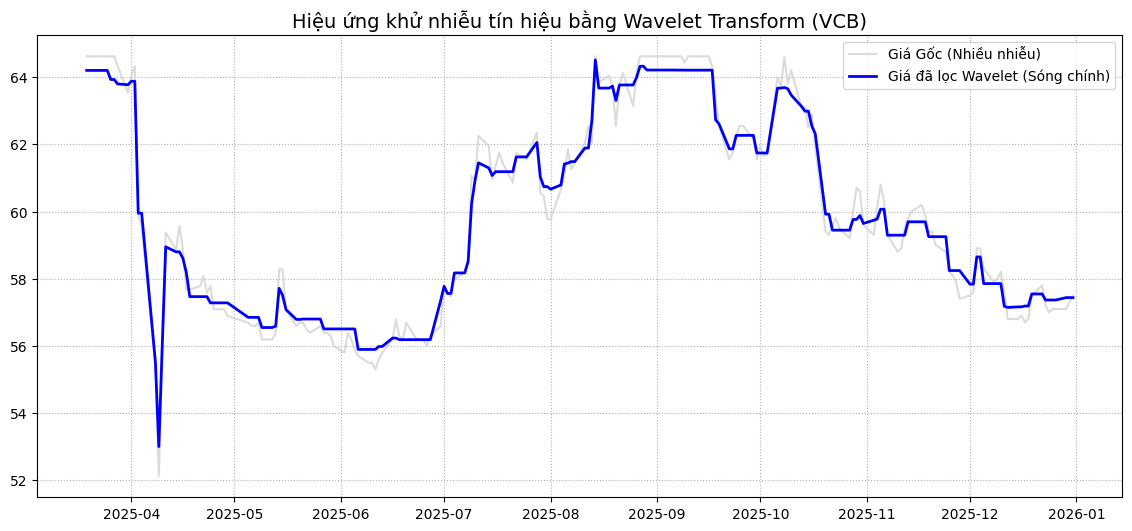

In [ ]:
import numpy as np
import os
import pandas as pd

processed_data_dict = {}
print("Đang tiến hành Kỹ sư đặc trưng (Phiên bản Chuẩn)...")

for ticker in tickers:
    df = raw_data_dict[ticker].copy()
    
    # 1. Nội suy tuyến tính
    df['close'] = df['close'].interpolate(method='linear')
    df['volume'] = df['volume'].interpolate(method='linear')
    
    # 2. Winsorization (Giới hạn ngoại lai ở phân vị 1% và 99%)
    lower_bound = df['close'].quantile(0.01)
    upper_bound = df['close'].quantile(0.99)
    df['close_winsorized'] = np.clip(df['close'], lower_bound, upper_bound)
    
    # 3. Kỹ sư đặc trưng (Tính trên nền giá Winsorized)
    df['sma_10'] = df['close_winsorized'].rolling(window=10).mean()
    df['sma_20'] = df['close_winsorized'].rolling(window=20).mean()
    
    delta = df['close_winsorized'].diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
    rs = gain / loss
    df['rsi_14'] = 100 - (100 / (1 + rs))
    
    df.dropna(inplace=True)
    df = df.reset_index(drop=True)
    
    processed_data_dict[ticker] = df
    os.makedirs('../data/processed', exist_ok=True)
    df.to_csv(f'../data/processed/{ticker}_features.csv', index=False)
    
    print(f"✅ Đã xử lý chuẩn xong {ticker}: Còn lại {len(df)} dòng dữ liệu.")

## Chuyển đổi Không gian Dữ liệu thành 3D Tensor

In [15]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import pickle
import os

# 1. Tải dữ liệu đã qua tiền xử lý của VCB
df_vcb = pd.read_csv('../data/processed/VCB_features.csv')

# Chọn các đặc trưng đầu vào (Features) và Biến mục tiêu (Target)
features = ['open', 'high', 'low', 'close_winsorized', 'volume', 'sma_10', 'sma_20', 'rsi_14']
target_col = 'close_winsorized' # Dự báo giá đóng cửa đã làm sạch

data_values = df_vcb[features].values
target_values = df_vcb[[target_col]].values

# 2. Chia tập dữ liệu TRƯỚC khi chuẩn hóa (Ngăn chặn Data Leakage)
# Tỷ lệ: 80% Train, 10% Validation, 10% Test
n = len(df_vcb)
train_end = int(n * 0.8)
val_end = int(n * 0.9)

train_data = data_values[:train_end]
val_data = data_values[train_end:val_end]
test_data = data_values[val_end:]

train_target = target_values[:train_end]
val_target = target_values[train_end:val_end]
test_target = target_values[val_end:]

# 3. Min-Max Scaling: CHỈ fit trên tập Train
feature_scaler = MinMaxScaler(feature_range=(0, 1))
target_scaler = MinMaxScaler(feature_range=(0, 1))

# Fit và Transform trên Train
scaled_train_data = feature_scaler.fit_transform(train_data)
scaled_train_target = target_scaler.fit_transform(train_target)

# CHỈ Transform (không fit) trên Val và Test
scaled_val_data = feature_scaler.transform(val_data)
scaled_val_target = target_scaler.transform(val_target)
scaled_test_data = feature_scaler.transform(test_data)
scaled_test_target = target_scaler.transform(test_target)

# Lưu Scaler lại để dùng cho ứng dụng web (để inverse_transform dự báo về giá VNĐ thực)
os.makedirs('../models', exist_ok=True)
with open('../models/vcb_target_scaler.pkl', 'wb') as f:
    pickle.dump(target_scaler, f)

# 4. Kỹ thuật Cửa sổ trượt (Sliding Window)
def create_sequences(data, target, window_size=30):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:(i + window_size)])
        y.append(target[i + window_size])
    return np.array(X), np.array(y)

window_size = 30
X_train, y_train = create_sequences(scaled_train_data, scaled_train_target, window_size)
X_val, y_val = create_sequences(scaled_val_data, scaled_val_target, window_size)
X_test, y_test = create_sequences(scaled_test_data, scaled_test_target, window_size)

# In ra Shape để kỹ sư AI (là bạn) kiểm chứng lại Tensor
print("🚀 Đã hoàn tất chuyển đổi 3D Tensor cho VCB!")
print("-" * 40)
print(f"Kích thước X_train: {X_train.shape} -> [Số batch, Cửa sổ {window_size} ngày, {len(features)} Đặc trưng]")
print(f"Kích thước y_train: {y_train.shape} -> [Số batch, 1 Giá trị dự báo]")
print("-" * 40)
print(f"X_val shape:  {X_val.shape}, y_val shape:  {y_val.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

🚀 Đã hoàn tất chuyển đổi 3D Tensor cho VCB!
----------------------------------------
Kích thước X_train: (2022, 30, 8) -> [Số batch, Cửa sổ 30 ngày, 8 Đặc trưng]
Kích thước y_train: (2022, 1) -> [Số batch, 1 Giá trị dự báo]
----------------------------------------
X_val shape:  (227, 30, 8), y_val shape:  (227, 1)
X_test shape: (227, 30, 8), y_test shape: (227, 1)
